# **Experiment: Interpreting Russian Case Relations with word2vec (PCA/LDA)**



## Data Loading

In [196]:
!curl -O https://raw.githubusercontent.com/UniversalDependencies/UD_Russian-SynTagRus/refs/heads/master/ru_syntagrus-ud-train-b.conllu

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 41.5M  100 41.5M    0     0  8712k      0  0:00:04  0:00:04 --:--:-- 11.2M


In [197]:
with open('ru_syntagrus-ud-train-b.conllu', 'r', encoding='utf-8') as f:
        data = f.read()

In [198]:
import pandas as pd

In [199]:
def parse_conllu_manual(file_path):
    tokens = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()

            # skip empty lines and comments
            if not line or line.startswith('#'):
              continue

            # split by tab
            parts = line.split('\t')

            token = {
                'ID': parts[0],
                'FORM': parts[1],
                'LEMMA': parts[2],
                'POS': parts[3], # part-of-speech tag
                'FEATS': parts[5], # grammatical features
            }
            tokens.append(token)

    return pd.DataFrame(tokens)

In [200]:
df = parse_conllu_manual('ru_syntagrus-ud-train-b.conllu')
df.head(10)

,ID,FORM,LEMMA,POS,FEATS
0,1,Премьер-министр,премьер-министр,NOUN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing
1,2,РФ,РФ,PROPN,Abbr=Yes|NameType=Geo
2,3,Владимир,Владимир,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|NameType=Giv...
3,4,Путин,Путин,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|NameType=Sur...
4,5,подписал,подписать,VERB,Aspect=Perf|Gender=Masc|Mood=Ind|Number=Sing|T...
5,6,распоряжение,распоряжение,NOUN,Animacy=Inan|Case=Acc|Gender=Neut|Number=Sing
6,7,о,о,ADP,_
7,8,переводе,перевод,NOUN,Animacy=Inan|Case=Loc|Gender=Masc|Number=Sing
8,9,Государственного,государственный,ADJ,Case=Gen|Degree=Pos|Gender=Masc|Number=Sing
9,10,университета,университет,NOUN,Animacy=Inan|Case=Gen|Gender=Masc|Number=Sing


## Exploratory Data Analysis: Case Distribution

In [201]:
syntagrus_nouns = df[(df['POS'] == 'NOUN') | (df['POS'] == 'PROPN')].copy()
syntagrus_nouns.shape

(126837, 5)

There are 126837 nouns in the dataset. Let's see their case distribution.

In [202]:
# extracting case from feats into a separate column
syntagrus_nouns.loc[:, 'CASE'] = syntagrus_nouns['FEATS'].str.extract(r'Case=([A-Za-z][A-Za-z]*)')
syntagrus_nouns['CASE'] = syntagrus_nouns['CASE'].fillna('none')

In [203]:
syntagrus_nouns.head()

,ID,FORM,LEMMA,POS,FEATS,CASE
0,1,Премьер-министр,премьер-министр,NOUN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing,Nom
1,2,РФ,РФ,PROPN,Abbr=Yes|NameType=Geo,none
2,3,Владимир,Владимир,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|NameType=Giv...,Nom
3,4,Путин,Путин,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|NameType=Sur...,Nom
5,6,распоряжение,распоряжение,NOUN,Animacy=Inan|Case=Acc|Gender=Neut|Number=Sing,Acc


In [204]:
syntagrus_nouns['CASE'].value_counts()

,count
CASE,
Gen,42116
Nom,31712
Acc,20641
Loc,13764
Ins,9610
Dat,6745
none,2204
Par,42
Voc,3


In [205]:
syntagrus_nouns[syntagrus_nouns['CASE'] == 'none'].head()

,ID,FORM,LEMMA,POS,FEATS,CASE
1,2,РФ,РФ,PROPN,Abbr=Yes|NameType=Geo,none
15,16,ГУ-ВШЭ,ГУ-ВШЭ,PROPN,Abbr=Yes|NameType=Com,none
23,24,РФ,РФ,PROPN,Abbr=Yes|NameType=Geo,none
29,5,ГУ-ВШЭ,ГУ-ВШЭ,PROPN,Abbr=Yes|NameType=Com,none
57,1,ВШЭ,ВШЭ,PROPN,Abbr=Yes|NameType=Com,none


In [206]:
# nouns without a case tag are mostly abbreviations; we will filter them out
syntagrus_nouns = syntagrus_nouns[syntagrus_nouns['CASE'] !='none']

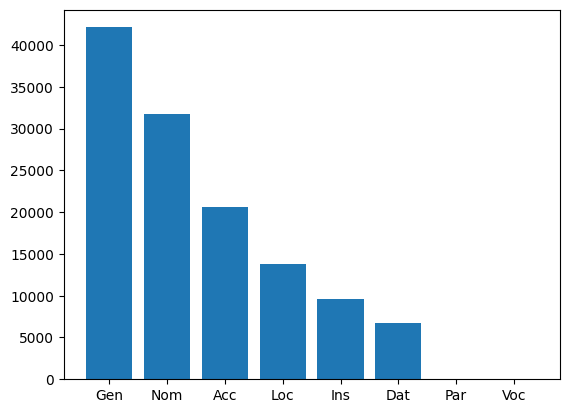

In [207]:
import matplotlib.pyplot as plt

plt.bar(syntagrus_nouns['CASE'].value_counts().index, syntagrus_nouns['CASE'].value_counts().values)
plt.show()

In [208]:
percentages = round(syntagrus_nouns['CASE'].value_counts(normalize=True) * 100, 4)
percentages

,proportion
CASE,
Gen,33.7920
Nom,25.4443
Acc,16.5614
Loc,11.0436
Ins,7.7106
Dat,5.4119
Par,0.0337
Voc,0.0024


**Strong imbalance** in the representation of case categories. There is a significant predominance of the *genitive* case – 33.8%. Among the "main" cases, the *dative* is the least represented in the corpus – 5.4%.

*Partitive and vocative* forms account for less than 1% of all wordforms. They will be **filtered out** during the dimensionality reduction stage.

## Data Preprocessing

In [209]:
len(df)

445322

In [210]:
# delete punctuation
df = df[df['POS'] != 'PUNCT']
df = df.reset_index(drop=True)

In [211]:
len(df)

365334

Instead of vectorizing raw forms, we concatenate each form with its morphological tag (`form_grammeme`). This captures grammatical features. The original DataFrame is transformed accordingly.

In [212]:
df['FORM+TAGS'] = df['FORM'] + '_' + df['POS'] + '_' + df['FEATS']
df.head(3)

,ID,FORM,LEMMA,POS,FEATS,FORM+TAGS
0,1,Премьер-министр,премьер-министр,NOUN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing,Премьер-министр_NOUN_Animacy=Anim|Case=Nom|Gen...
1,2,РФ,РФ,PROPN,Abbr=Yes|NameType=Geo,РФ_PROPN_Abbr=Yes|NameType=Geo
2,3,Владимир,Владимир,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|NameType=Giv...,Владимир_PROPN_Animacy=Anim|Case=Nom|Gender=Ma...


Now we will add a `SENTENCE_ID` column that stores the ID of the sentence to which each word belongs. Then we will use this ID to create a `SENT_WITH_TAGS` column containing the full sentences (formed from tokens with their tags).

In [213]:
sent_id = 0
for index, row in df.iterrows():
  if row['ID'] == '1':
    sent_id += 1
  df.loc[index, 'SENTENCE_ID'] = f's{sent_id}'

In [214]:
df['SENT_WITH_TAGS'] = df.groupby('SENTENCE_ID')['FORM+TAGS'].transform(lambda x: ' '.join(x))

In [215]:
import nltk
nltk.download("punkt_tab")

def clean_text(text, tokenizer):
  text = text.lower()
  tokens = tokenizer(text)
  return tokens

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [216]:
docs = df["SENT_WITH_TAGS"].drop_duplicates().tolist()
tokens = list(map(lambda x: clean_text(x, nltk.word_tokenize), docs))

## Training Word2vec

In [217]:
!pip install gensim

In [218]:
from gensim.models import Word2Vec
syntagrus_model = Word2Vec(sentences=tokens, vector_size=300, window=5, min_count=2, sg=0) # CBOW
len(syntagrus_model.wv)

30953

## Dimensionality Reduction (PCA, LDA) and Visualization

###  PCA — Principal Component Analysis

In [219]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import numpy as np

In [220]:
import re
case_pattern = re.compile(r'case=(\w+)')

In [221]:
noun_tokens = [word for word in syntagrus_model.wv.index_to_key
               if ('noun_' in word.lower() or 'propn_' in word.lower())
               and case_pattern.search(word) and 'case=voc' not in word and 'case=par' not in word]
# filtering out the partitive and vocative as together make up less than 1% of the dataset.

In [222]:
# getting embeddings for nouns only
word_vectors = syntagrus_model.wv[noun_tokens]

# reducing dimensionality to 3D
pca = PCA(n_components=3)
result_3d = pca.fit_transform(word_vectors)

In [223]:
def get_case(token):
    for case in ['nom', 'gen', 'dat', 'acc', 'ins', 'loc', 'par', 'voc']:
        if f'case={case}' in token:
            return case

In [224]:
cases = [get_case(token) for token in noun_tokens if get_case(token) not in ['par', 'voc', None]]

In [225]:
color_map = {
    'nom': 'red',
    'gen': 'blue',
    'dat': 'green',
    'acc': 'orange',
    'ins': 'purple',
    'loc': 'brown',
}
colors = [color_map[case] for case in cases]

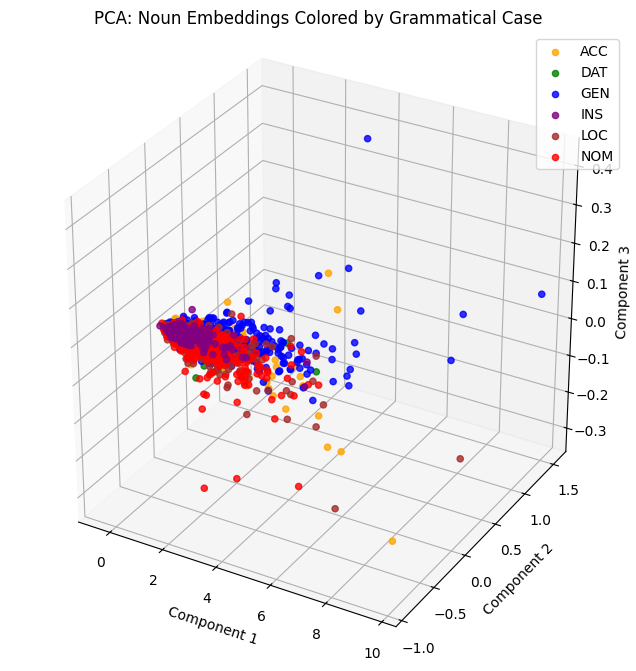

In [226]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

unique_cases = sorted(set(cases))
for case in unique_cases:
    mask = [c == case for c in cases]
    ax.scatter(
        xs = result_3d[mask, 0],
        ys = result_3d[mask, 1],
        zs = result_3d[mask, 2],
        c=color_map[case],
        alpha=0.8,
        s=20,
        label=case.upper()
    )

ax.legend(loc='best', shadow=False, scatterpoints=1)

ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')

ax.set_box_aspect([1, 1, 1])

plt.title('PCA: Noun Embeddings Colored by Grammatical Case')
plt.show()

In [227]:
!pip install plotly

In [228]:
import plotly.graph_objects as go
import plotly.express as px

In [229]:
fig = go.Figure()

for case in unique_cases:
    mask = [c == case for c in cases]
    x_case = result_3d[mask, 0]
    y_case = result_3d[mask, 1]
    z_case = result_3d[mask, 2]
    tokens_case = [noun_tokens[i] for i, m in enumerate(mask) if m]

    fig.add_trace(go.Scatter3d(
        x=x_case,
        y=y_case,
        z=z_case,
        mode='markers',
        marker=dict(
            size=5,
            color=color_map.get(case, 'gray'),
            opacity=0.8
        ),
        text=tokens_case,
        hoverinfo='text',
        name=case.upper()
    ))

fig.update_layout(
    title="PCA: Noun Embeddings Colored by Grammatical Case (Interactive)",
    scene=dict(
        xaxis_title='PCA Component 1',
        yaxis_title='PCA Component 2',
        zaxis_title='PCA Component 3',
        aspectmode='cube'
    ),
    width=1000,
    height=700
)

fig.show()

The resulting clusters are **poorly interpretable**. One possible reason is that PCA is an *unsupervised method* that maximizes variance without any guidance from case labels. The principal components may therefore reflect other patterns in the data – such as distributional semantics, word frequency, or other morphological features – rather than case distinctions.

However, the weak clustering might also indicate that case information is not strongly encoded in the word2vec vectors themselves, regardless of the dimensionality reduction technique.

### LDA - Linear Discriminant Analysis

Linear Discriminant Analysis (LDA), in contrast to PCA, is a *supervised* dimensionality reduction method. It uses the case labels to find projections that maximize between-class separation while minimizing within-class variance. In principle, providing explicit case information could yield more interpretable clusters.

In [230]:
vectors = syntagrus_model.wv.vectors
tokens = syntagrus_model.wv.index_to_key

In [231]:
X_list = []
y_list = []
nun_tokens = []

for token, vec in zip(tokens, vectors):

    case_match = case_pattern.search(token)
    if ('noun_' not in token and 'propn_' not in token) or not case_match or 'case=par' in token or 'case=voc' in token:
        continue

    case = case_match.group(1)

    X_list.append(vec)
    y_list.append(case)
    noun_tokens.append(token)

X = np.array(X_list)
y = np.array(y_list)

In [232]:
X.shape

(15520, 300)

In [233]:
y.shape

(15520,)

In [234]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [235]:
lda = LinearDiscriminantAnalysis(n_components=3)
X_r3 = lda.fit(X, y).transform(X)

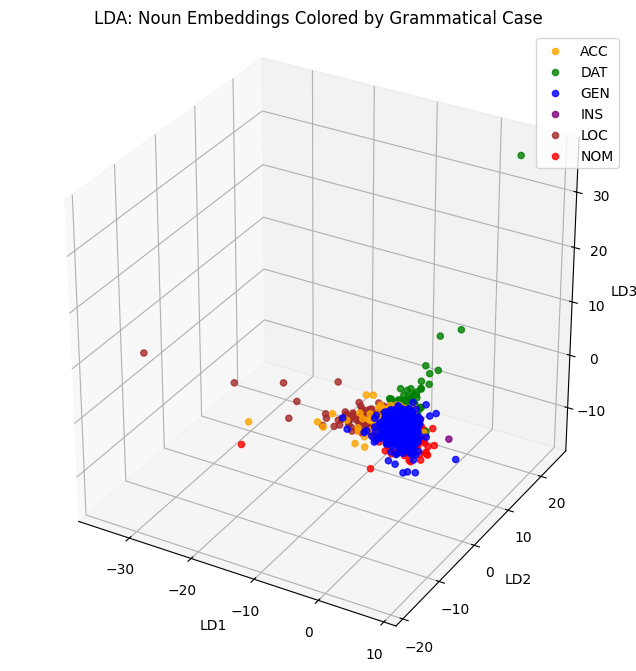

In [236]:
unique_cases = np.unique(y)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for case in unique_cases:
    mask = (y == case)
    ax.scatter(
        X_r3[mask, 0],
        X_r3[mask, 1],
        X_r3[mask, 2],
        c=color_map[case],
        alpha=0.8,
        s=20,
        label=case.upper()
    )

ax.legend(loc='best', shadow=False, scatterpoints=1)

ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_zlabel('LD3')

ax.set_box_aspect([1, 1, 1])

plt.title('LDA: Noun Embeddings Colored by Grammatical Case')
plt.show()

In [237]:
data = []
for case in unique_cases:
    mask = (y == case)
    x_vals = X_r3[mask, 0]
    y_vals = X_r3[mask, 1]
    z_vals = X_r3[mask, 2]
    tokens_case = [noun_tokens[i] for i, m in enumerate(mask) if m]

    trace = go.Scatter3d(
        x=x_vals, y=y_vals, z=z_vals,
        mode='markers',
        marker=dict(color=color_map[case], size=5, opacity=0.8),
        name=case.upper(),
        text=tokens_case,
        hoverinfo='text'
    )
    data.append(trace)

layout = go.Layout(
    title='LDA: Noun Embeddings Colored by Grammatical Case (Interactive)',
    scene=dict(
        xaxis_title='X axis',
        yaxis_title='Y axis',
        zaxis_title='Z axis',
        aspectmode='cube'
    ),
    width=800,
    height=600,
    legend=dict(
        x=0.8, y=0.9,
        bordercolor='black',
        borderwidth=1
    )
)

fig = go.Figure(data=data, layout=layout)
fig.show()

The overall spread of points is small, and same-case vectors form tight, compact clusters. Different cases are located close to each other but are separated by direction: points belonging to the same case tend to radiate in a common orientation. This makes the plot **slightly more interpretable** than PCA, where no such directional consistency was observed.

However, the clusters overlap, and there are no clear boundaries between them. This suggests that word2vec may not capture case distinctions robustly enough for clean clustering, at least in this experimental setup.

Future work with subword-aware models (FastText) or contextualized embeddings (BERT) could potentially capture morphological and case information more effectively.